#Ames Housing Price Regression Project

##Introduction
Accurate real estate valuation is a significant problem in housing markets, affecting buyers, sellers, financial institutions, insurers, and urban planners. Property prices are influenced by a combination of structural characteristics, neighborhood quality, construction details, and economic factors, making price estimation a naturally multivariate problem.

This project develops an end-to-end machine learning pipeline for predicting residential property prices using the Ames Housing Dataset. The dataset contains detailed information on residential homes in Ames, Iowa, including physical attributes, quality ratings, location-based variables, and sale conditions.

Unlike simplistic regression demonstrations, this project emphasizes both statistical rigor and machine learning engineering practices. The workflow includes:
- exploratory data analysis (EDA),
- missing value treatment,
- feature engineering,
- multicollinearity analysis,
- regression diagnostics,
- model evaluation and comparison, and
- deployment-oriented pipeline design.

The primary objective is to build interpretable and robust regression models capable of estimating housing prices while also examining the underlying relationships between housing characteristics and market value.

I begin by importing necessary libraries and also importing the dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
from sklearn.datasets import fetch_openml

ames = fetch_openml(data_id=42165, as_frame=True)

df = ames.frame

In [3]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
df.shape

(1460, 81)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

# Features Overview

The dataset consists of 81 variables describing housing properties. These variables can be meaningfully grouped into structural, spatial, quality, temporal, interior, exterior, and sale-related dimensions. This grouping will guide preprocessing, feature engineering, and modeling decisions.

1. **Location, Zoning, and Lot Characteristics**

This group describes the spatial and regulatory context of each property. It captures where the house is located, how the land is configured, and the environmental constraints or access conditions affecting the property. These variables are primarily categorical (nominal and ordinal mix) with some continuous measures of lot size.

Variables: MSSubClass, MSZoning, LotFrontage, LotArea, Street, Alley, LotShape, LandContour, Utilities, LotConfig, LandSlope, Neighborhood, Condition1, Condition2

2. **Structural and Building Type Features**

This group defines the physical structure and architectural classification of the dwelling. It captures what kind of building exists and how it is fundamentally constructed or styled. These variables are mostly nominal categorical with some ordinal quality indicators.

Variables: BldgType, HouseStyle, OverallQual, OverallCond

3. **Construction Timeline and Renovation Features**
This group captures the temporal evolution of the property, including original construction and later modifications. These variables are central for engineering age-based features and capturing depreciation or modernization effects.

Variables: YearBuilt, YearRemodAdd

4. **Exterior Material and Quality Features**

This group describes the external composition and finishing of the house. It includes both categorical material types and ordinal quality assessments of exterior conditions.

Variables: RoofStyle, RoofMatl, Exterior1st, Exterior2nd, MasVnrType, MasVnrArea, ExterQual, ExterCond, Foundation

5. **Basement Features**

This group captures basement structure, quality, exposure, finishing, and usable area. It is a mixed group of ordinal ratings and continuous area measurements. Basement features are often highly predictive of price but also prone to missingness patterns that carry meaning.

Variables: BsmtQual, BsmtCond, BsmtExposure, BsmtFinType1, BsmtFinSF1, BsmtFinType2, BsmtFinSF2, BsmtUnfSF, TotalBsmtSF

6. **Heating, Utilities, and Electrical Systems**

This group describes core building utilities and infrastructure systems that affect livability and functionality. It contains nominal categorical variables and ordinal quality ratings.

Variables: Heating, HeatingQC, CentralAir, Electrical

7. **Interior Living Area and Space Distribution**

This group describes usable living space across floors and quality-adjusted areas. These variables are continuous and often highly correlated, making them important for multicollinearity handling.

Variables: 1stFlrSF, 2ndFlrSF, LowQualFinSF, GrLivArea

8. **Household Composition and Room Structure**

This group captures internal layout structure, including rooms and bathrooms. These are discrete count variables and often proxy for household size and functional capacity.

Variables: BsmtFullBath, BsmtHalfBath, FullBath, HalfBath, BedroomAbvGr, KitchenAbvGr, TotRmsAbvGrd, Functional

9. **Kitchen and Fireplaces**

This group captures specific interior features related to kitchen quality and fireplace presence. These are mostly ordinal categorical variables with some count features.

Variables: KitchenQual, Fireplaces, FireplaceQu

10. **Garage Features**

This group captures garage structure, size, quality, and construction timing. It includes both continuous measurements and ordinal quality indicators.

Variables: GarageType, GarageYrBlt, GarageFinish, GarageCars, GarageArea, GarageQual, GarageCond

11. **Outdoor and Miscellaneous Property Features**

This group includes external amenities such as decks, porches, pools, fencing, and additional non-core features. Many of these variables are sparse but can be highly nonlinear in their impact on price.

Variables: WoodDeckSF, OpenPorchSF, EnclosedPorch, 3SsnPorch, ScreenPorch, PoolArea, PoolQC, Fence, MiscFeature, MiscVal

12. **Time of Sale and Transaction Features**

This group captures when the property was sold and under what conditions. These variables are useful for seasonality effects and market condition adjustments.

Variables: MoSold, YrSold, SaleType, SaleCondition

13. **Target Variable**
This is the response variable for regression modeling.

Variable: SalePrice

In this section I fill the nan values with zero because when a feature is not specified, it means the feature was absent.



In [6]:
nan_df = df.isna().sum()
nan_df = nan_df.loc[nan_df > 0]
nan_df.sort_values(ascending=False)

,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
FireplaceQu,690
LotFrontage,259
GarageCond,81
GarageType,81
GarageYrBlt,81
GarageFinish,81


# Splitting the Data

In the following section I split the data into train and test before any preprocessing is done. This is to prevent data leakage.

I also make the split stratified to keep certain proportion of variaables equal.

In [7]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(
    df, test_size=0.2, random_state=46,
    stratify=df['Street']
)

print(train.shape)
print(test.shape)

(1168, 81)
(292, 81)


# Feature Engineering

In this section, the raw dataset will be transformed into a more structured and model-ready feature space through a combination of feature creation, feature transformation, and feature removal. The objective will be to ensure that each retained variable contributes a distinct and interpretable signal about the underlying housing characteristics, while minimizing redundancy and unnecessary complexity in the input space.

New features will be introduced to better capture structural properties that are currently distributed across multiple fragmented variables. For example, aggregated area features such as total porch space will be constructed to represent combined functional space rather than relying on multiple overlapping porch-type variables. In addition, binary indicator variables will be created to capture the presence or absence of key structural components (such as additional floors, basement sections, or masonry veneer), since the existence of these features often introduces meaningful discontinuities in property valuation that are not fully captured by raw magnitude alone.

Several variables will also be transformed to improve interpretability and modeling behavior. Temporal variables such as construction and renovation years will be converted into age-based representations relative to the sale year, allowing the model to learn directly from time decay effects rather than raw calendar values. Similar transformations will be applied where raw numerical values are less informative than derived structural interpretations.

At the same time, redundant and highly overlapping features will be removed to avoid repeated encoding of the same underlying housing attributes. This will include decomposed area variables that will be replaced by aggregated counterparts, as well as strongly correlated structural measurements that will not provide independent explanatory value beyond other retained variables. This reduction step will be guided by prior multicollinearity analysis, ensuring that only stable and non-overlapping signals remain in the final feature set.

Overall, the feature engineering process will move the dataset from a raw measurement-based representation into a more compact and structured form, where variables are aligned more closely with interpretable housing characteristics rather than fragmented physical decompositions.

# Variance Inflation Factor

In this dataset the numeric variables are highly colinear, e.g
- `GarageCars` increases as `GarageArea` increases,
- `TotalBsmtSF` = `BsmtFinSF1` + `BsmtFinSF2` + `BsmtUnfSF`, and
- `GrLivArea` = `1stFlrSF` + `2ndFlrSF`

This introduces multicollinearity and redundancy and leads to:
- inflated standard errors,
- unstable coefficients,
- poor interpretability, and
- misleading feature importance.

To remedy this, I conduct the Variance Inflation Test (VIF) to detect multicollinearity and merge and drop redundant variables.

The Variance Inflation Factor measures how well a predictor variable can be interpreted by other predictor variables, and it is calculated as:

For a variable $X_j$,

$$VIF_j = \frac{1}{1 - R_j^2}$$



In [8]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def vif_check(data):

    number_df = data.select_dtypes(
        include=['int64', 'float64']
    ).fillna(0)
    number_df = number_df.drop(columns=[
        'Id', 'SalePrice', 'YearBuilt',
        'YearRemodAdd', 'GarageYrBlt',
        'YrSold', 'MoSold'
        ])

    vif_data = pd.DataFrame()
    vif_data["feature"] = number_df.columns
    vif_data["VIF"] = [
        variance_inflation_factor(number_df.values, i)
        for i in range(number_df.shape[1])
    ]

    vif_data = vif_data.sort_values(
        by="VIF", ascending=False
    ).reset_index(drop=True)

    return vif_data

vif_check(train)

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,feature,VIF
0,BsmtFinSF1,inf
1,LowQualFinSF,inf
2,2ndFlrSF,inf
3,1stFlrSF,inf
4,TotalBsmtSF,inf
5,BsmtUnfSF,inf
6,BsmtFinSF2,inf
7,GrLivArea,inf
8,TotRmsAbvGrd,86.125318
9,OverallQual,48.663010


# Interpretation

According to the above values, it is clear that the first 16 vatiables exhibit multicollinearity.

In the following function, I add new features that capture the colinearity and drop some features.

In [9]:
def remedy_colinearity(data):

    data = data.copy()

    data['hasBsmt2'] = data['BsmtFinSF2'].apply(
        lambda x: 1 if x > 0 else 0)
    data['hasFlr2'] = data['2ndFlrSF'].apply(
        lambda x: 1 if x > 0 else 0)
    data['TotalPorch'] = (
        data['OpenPorchSF'] + data['EnclosedPorch'] +
        data['3SsnPorch'] + data['ScreenPorch'])
    data['hasWoodDeck'] = data['WoodDeckSF'].apply(
        lambda x: 1 if x > 0 else 0)
    data['hasPorch'] = data['TotalPorch'].apply(
        lambda x: 1 if x > 0 else 0)
    data['isMultiKitchen'] = data['KitchenAbvGr'].apply(
        lambda x: 1 if x > 1 else 0)
    data['OtherRooms'] = (
        data['TotRmsAbvGrd'] - data['BedroomAbvGr'] -
        data['KitchenAbvGr']
    )
    data['hasBsmt1'] = data['BsmtFinSF1'].apply(
        lambda x: 1 if x > 0 else 0)
    data['hasMasVnr'] = data['MasVnrArea'].apply(
        lambda x: 1 if x > 0 else 0)

    data = data.drop(columns=[
        'BsmtFinSF1', 'BsmtFinSF2',
        'BsmtUnfSF', 'TotRmsAbvGrd',
        'GarageCars', '2ndFlrSF',
        'LowQualFinSF', '1stFlrSF',
        'OpenPorchSF', 'EnclosedPorch',
        '3SsnPorch', 'ScreenPorch',
        'KitchenAbvGr',
        'OverallCond', 'OverallQual',
        'GrLivArea', 'BsmtFullBath',
        'BsmtHalfBath', 'TotalBsmtSF',
        'MasVnrArea', 'WoodDeckSF'
    ])

    return data


In [10]:
train_z = remedy_colinearity(train)

vif_check(train_z)

,feature,VIF
0,FullBath,16.710984
1,BedroomAbvGr,12.802704
2,OtherRooms,10.408377
3,GarageArea,9.428344
4,hasPorch,5.135585
5,hasFlr2,4.365761
6,LotFrontage,4.215994
7,MSSubClass,3.490522
8,hasBsmt1,3.476374
9,HalfBath,2.818346


## Feature Engineering & Dimensionality Reduction Rationale

At this stage, the dataset has been reshaped to remove redundant structure and reduce repeated representation of the same underlying housing attributes across multiple variables.

Many of the original numerical features had described the same physical property from different decomposed perspectives (for example, total area versus its component parts, or total room counts versus sub-room counts). Leaving these variables in their raw form would have resulted in multiple overlapping signals, where the same underlying attribute was effectively being represented more than once in slightly different forms.

To address this, several transformations have been applied.

---

### 1. Aggregation of split structural measurements

Where a single physical attribute had been fragmented across multiple columns, those components have been consolidated into a single representative feature.

For example:
- Porch-related variables have been combined into `TotalPorch`, since they collectively describe total exterior porch exposure regardless of type.

This ensured that porch space is represented as a single coherent signal rather than multiple partially overlapping measurements.

---

### 2. Conversion of continuous decompositions into structural indicators

Certain continuous variables have been reduced into binary presence indicators where the primary signal of interest has been whether a structural component exists rather than its exact magnitude.

For example:
- Basement and upper-floor variables have been partially transformed into `hasBsmt1`, `hasBsmt2`, and `hasFlr2`

This reflects the fact that the presence of certain structural elements tends to introduce discrete shifts in property valuation that are not fully captured by continuous measurements alone.

---

### 3. Reduction of overlapping spatial representations

Several area-based variables had described overlapping spatial constructs (for example, total living area versus floor-level decompositions). In these cases, redundant representations have been removed, and only the most stable or interpretable form has been retained.

This prevented the same spatial information from being repeatedly encoded across multiple correlated variables.

---

### 4. Simplification of redundant structural counts

Certain count-based variables had provided overlapping information about household capacity or layout. These have been simplified where multiple variables encoded closely related structural signals.

In cases where variables had conveyed the same underlying structural capacity in different forms, only one representation has been retained to avoid duplication of signal.

---

### 5. Removal of strongly overlapping quality signals

Some variables had combined strongly with other structural or size-based features in a way that did not provide independent explanatory information. These have been removed to avoid repeatedly encoding the same latent housing quality signal through multiple correlated proxies.

---

### 6. Resulting feature design principle

The resulting feature set has been constructed around the following principles:

- each structural concept is represented once in the dataset
- magnitude and existence effects have been separated where they convey distinct information
- overlapping spatial and structural decompositions have been consolidated into single representations
- redundant proxies of housing quality have been removed where they duplicated existing signals

Overall, the feature space has been reorganized to ensure that each remaining variable contributes a distinct and non-overlapping representation of the underlying housing structure.

---

In the following code, additional variables such as `Age`, `GarageAge`, and other derived structural features will be created from existing columns to produce more meaningful representations of the housing properties. Redundant variables will also be removed where necessary to reduce overlapping information within the feature space.

Finally, the predictor variables (`X`) and target variable (`y`) will be defined in preparation for preprocessing and model training.

In [11]:
def more_features(data):

    data = data.copy()

    data['Age'] = data['YrSold'] - data['YearBuilt']
    data['GarageAge'] = data['YrSold'] - data['GarageYrBlt']
    data['RemodAge'] = data['YrSold'] - data['YearRemodAdd']
    data['hasPool'] = data['PoolArea'].apply(
        lambda x: 1 if x > 0 else 0
    )

    data = data.drop(columns=[
        'YearBuilt', 'YearRemodAdd',
        'GarageYrBlt', 'YrSold', "MoSold",
        'Id', "MiscFeature", 'PoolQC',
        'PoolArea'
    ])

    return data

def semi_final_step(data):

    data = data.copy()

    num_cols = data.select_dtypes(
        include=['int64', 'float64']
    )
    obj_cols = data.select_dtypes(
        include=['object']
    )

    for each in num_cols:
        data[each] = data[each].fillna(0)

    for each in obj_cols:
        data[each] = data[each].fillna('NA')

    data = remedy_colinearity(data)
    data = more_features(data)
    misc_val = None

    try:
        misc_val = data['MiscVal']
        data['NetSalePrice'] = (
            data['SalePrice'] - data['MiscVal'])
        data = data.drop([
            'SalePrice', 'MiscVal'], axis=1)
    except:
        data['NetSalePrice'] = data['SalePrice']
        data = data.drop([
            'SalePrice', 'MiscVal'], axis=1)

    X = data.drop('NetSalePrice', axis=1)
    y = data['NetSalePrice']

    return X, y, misc_val


# Data Transformation

In the following section I apply transformations to the columns. I encode the categorical columns and transform the scake the numerical columns.

In [12]:
ordinal_cols = [
    'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond',
    'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'HeatingQC', 'KitchenQual', 'FireplaceQu',
    'GarageQual', 'GarageCond', 'LotShape',
    'Fence', 'GarageFinish', 'Functional',
]
one_hot_cols = [
    'MSZoning', 'Street', 'Alley',
    'LandContour', 'Utilities', 'LotConfig',
    'LandSlope', 'Neighborhood', 'Condition1',
    'Condition2', 'BldgType', 'HouseStyle',
    'RoofStyle', 'RoofMatl', 'Exterior1st',
    'Exterior2nd', 'MasVnrType', 'Foundation',
    'Heating', 'CentralAir', 'Electrical',
    'GarageType', 'PavedDrive',
    'SaleType', 'SaleCondition', 'MSSubClass'
]
log_cols = [
    'LotFrontage', 'LotArea', 'TotalPorch',
    'GarageArea'
]

leave_cols = [
    'FullBath', 'HalfBath', 'BedroomAbvGr',
    'Fireplaces', 'Age',
    'GarageAge', 'RemodAge', 'OtherRooms'
]

In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
    RobustScaler,
    FunctionTransformer
)

# ==========================================
# ORDINAL CATEGORY ORDERINGS
# ==========================================

ordinal_categories = [

    ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
    ['Po', 'Fa', 'TA', 'Gd', 'Ex'],

    ['NA', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    ['NA', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],

    ['NA', 'No', 'Mn', 'Av', 'Gd'],

    ['NA', 'Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ'],
    ['NA', 'Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ'],

    ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
    ['Po', 'Fa', 'TA', 'Gd', 'Ex'],

    ['NA', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],

    ['NA', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    ['NA', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],

    ['IR3', 'IR2', 'IR1', 'Reg'],

    ['NA', 'MnWw', 'GdWo', 'MnPrv', 'GdPrv'],

    ['NA', 'Unf', 'RFn', 'Fin'],

    ['Sal', 'Sev', 'Maj2', 'Maj1',
     'Mod', 'Min2', 'Min1', 'Typ']
]


# ==========================================
# PIPELINES
# ==========================================

ordinal_pipeline = Pipeline([
    (
        'encoder',
        OrdinalEncoder(
            categories=ordinal_categories,
            handle_unknown='use_encoded_value',
            unknown_value=-1
        )
    ),
    ('scaler', RobustScaler())
])

one_hot_pipeline = Pipeline([
    (
        'onehot',
        OneHotEncoder(
            drop='first',
            handle_unknown='ignore',
            sparse_output=False
        )
    )
])

log_pipeline = Pipeline([
    ('log', FunctionTransformer(np.log1p)),
    ('scaler', RobustScaler())
])

leave_pipeline = Pipeline([
    ('scaler', RobustScaler())
])


# ==========================================
# COLUMN TRANSFORMER
# ==========================================

preprocessor = ColumnTransformer(
    transformers=[

        ('ordinal', ordinal_pipeline, ordinal_cols),

        ('onehot', one_hot_pipeline, one_hot_cols),

        ('log', log_pipeline, log_cols),

        ('scaled', leave_pipeline, leave_cols)

    ],

    remainder='passthrough',
    #force_int_remainder_cols=True
)

# Training and Selecting Models

In thiss section I train different models, evaluate them and select the best model.

In [14]:
from sklearn.linear_model import (
    LinearRegression, Ridge, Lasso)
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import HistGradientBoostingRegressor

In [15]:
lin_reg = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        random_state=30,
        n_jobs=-1
    ))
])

grad_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', HistGradientBoostingRegressor(
        random_state=30
    ))
])

ridge = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge(alpha=10))
])

lasso = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Lasso(alpha=0.001))
])

In [16]:
train_X, train_y, _ = semi_final_step(train)
train_y = np.log(train_y)

In [ ]:
lin_reg.fit(train_X, train_y)

In [18]:
rf_model.fit(train_X, train_y)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ordinal',
                                                  Pipeline(steps=[('encoder',
                                                                   OrdinalEncoder(categories=[['Po',
                                                                                               'Fa',
                                                                                               'TA',
                                                                                               'Gd',
                                                                                               'Ex'],
                                                                                              ['Po',
                                                                                               'Fa',
                                                                                               'TA',
                                                                                               'Gd',
                                                                                               'Ex'],
                                                                                              ['NA',
                                                                                               'Po',
                                                                                               'Fa',
                                                                                               'TA',
                                                                                               'Gd',
                                                                                               'Ex'],
                                                                                              ['NA',
                                                                                               'Po',
                                                                                               'Fa',
                                                                                               'TA',
                                                                                               'Gd',
                                                                                               'Ex'],
                                                                                              ['NA',
                                                                                               'No',
                                                                                               'Mn',
                                                                                               'Av',
                                                                                               'Gd'],
                                                                                              ['NA',
                                                                                               'Unf',
                                                                                               'LwQ',
                                                                                               'Rec',
                                                                                               'BLQ',
                                                                                               'ALQ',
                                                                                               'GLQ'],
                                                                                              ['NA',
                                                                                               'Un...
                                                  Pipeline(steps=[('log',
                                             

In [19]:
grad_model.fit(train_X, train_y)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ordinal',
                                                  Pipeline(steps=[('encoder',
                                                                   OrdinalEncoder(categories=[['Po',
                                                                                               'Fa',
                                                                                               'TA',
                                                                                               'Gd',
                                                                                               'Ex'],
                                                                                              ['Po',
                                                                                               'Fa',
                                                                                               'TA',
                                                                                               'Gd',
                                                                                               'Ex'],
                                                                                              ['NA',
                                                                                               'Po',
                                                                                               'Fa',
                                                                                               'TA',
                                                                                               'Gd',
                                                                                               'Ex'],
                                                                                              ['NA',
                                                                                               'Po',
                                                                                               'Fa',
                                                                                               'TA',
                                                                                               'Gd',
                                                                                               'Ex'],
                                                                                              ['NA',
                                                                                               'No',
                                                                                               'Mn',
                                                                                               'Av',
                                                                                               'Gd'],
                                                                                              ['NA',
                                                                                               'Unf',
                                                                                               'LwQ',
                                                                                               'Rec',
                                                                                               'BLQ',
                                                                                               'ALQ',
                                                                                               'GLQ'],
                                                                                              ['NA',
                                                                                               'Un...
                                                  Pipeline(steps=[('log',
                                             

In [20]:
ridge.fit(train_X, train_y)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ordinal',
                                                  Pipeline(steps=[('encoder',
                                                                   OrdinalEncoder(categories=[['Po',
                                                                                               'Fa',
                                                                                               'TA',
                                                                                               'Gd',
                                                                                               'Ex'],
                                                                                              ['Po',
                                                                                               'Fa',
                                                                                               'TA',
                                                                                               'Gd',
                                                                                               'Ex'],
                                                                                              ['NA',
                                                                                               'Po',
                                                                                               'Fa',
                                                                                               'TA',
                                                                                               'Gd',
                                                                                               'Ex'],
                                                                                              ['NA',
                                                                                               'Po',
                                                                                               'Fa',
                                                                                               'TA',
                                                                                               'Gd',
                                                                                               'Ex'],
                                                                                              ['NA',
                                                                                               'No',
                                                                                               'Mn',
                                                                                               'Av',
                                                                                               'Gd'],
                                                                                              ['NA',
                                                                                               'Unf',
                                                                                               'LwQ',
                                                                                               'Rec',
                                                                                               'BLQ',
                                                                                               'ALQ',
                                                                                               'GLQ'],
                                                                                              ['NA',
                                                                                               'Un...
                                                   'SaleCondition',
                                                   

In [21]:
lasso.fit(train_X, train_y)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ordinal',
                                                  Pipeline(steps=[('encoder',
                                                                   OrdinalEncoder(categories=[['Po',
                                                                                               'Fa',
                                                                                               'TA',
                                                                                               'Gd',
                                                                                               'Ex'],
                                                                                              ['Po',
                                                                                               'Fa',
                                                                                               'TA',
                                                                                               'Gd',
                                                                                               'Ex'],
                                                                                              ['NA',
                                                                                               'Po',
                                                                                               'Fa',
                                                                                               'TA',
                                                                                               'Gd',
                                                                                               'Ex'],
                                                                                              ['NA',
                                                                                               'Po',
                                                                                               'Fa',
                                                                                               'TA',
                                                                                               'Gd',
                                                                                               'Ex'],
                                                                                              ['NA',
                                                                                               'No',
                                                                                               'Mn',
                                                                                               'Av',
                                                                                               'Gd'],
                                                                                              ['NA',
                                                                                               'Unf',
                                                                                               'LwQ',
                                                                                               'Rec',
                                                                                               'BLQ',
                                                                                               'ALQ',
                                                                                               'GLQ'],
                                                                                              ['NA',
                                                                                               'Un...
                                                   'MSSubClass']),
                                                 ('l

In [22]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

In [23]:
train_y_exp = np.exp(train_y)

lin_reg_train_mae = mean_absolute_error(
    train_y_exp, np.exp(lin_reg.predict(train_X))
)

rf_model_train_mae = mean_absolute_error(
    train_y_exp, np.exp(rf_model.predict(train_X))
)

grad_model_train_mae = mean_absolute_error(
    train_y_exp, np.exp(grad_model.predict(train_X))
)

ridge_train_mae = mean_absolute_error(
    train_y_exp, np.exp(ridge.predict(train_X))
)

lasso_train_mae = mean_absolute_error(
    train_y_exp, np.exp(lasso.predict(train_X))
)


In [24]:
test_X, test_y, _ = semi_final_step(test)

In [25]:
lin_reg_test_mae = mean_absolute_error(
    test_y, np.exp(lin_reg.predict(test_X))
)

rf_model_test_mae = mean_absolute_error(
    test_y, np.exp(rf_model.predict(test_X))
)

grad_model_test_mae = mean_absolute_error(
    test_y, np.exp(grad_model.predict(test_X))
)

ridge_test_mae = mean_absolute_error(
    test_y, np.exp(ridge.predict(test_X))
)

lasso_test_mae = mean_absolute_error(
    test_y, np.exp(lasso.predict(test_X))
)


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [4, 13, 14, 15, 18, 20] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [4, 13, 14, 15, 18, 20] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [4, 13, 14, 15, 18, 20] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [4, 13, 14, 15, 18, 20] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-p

In [26]:
print(f'''

Linear Regression train MAE: {(lin_reg_train_mae)}
Linear Regression test MAE: {(lin_reg_test_mae)}

Random Forest train MAE: {(rf_model_train_mae)}
Random Forest test MAE: {(rf_model_test_mae)}

Gradient Boosting Model train MAE: {grad_model_train_mae}
Gradient Boosting Model test MAE: {grad_model_test_mae}

Ridge train MAE: {ridge_train_mae}
Ridge test MAE: {ridge_test_mae}

Lasso train MAE: {lasso_train_mae}
Lasso test MAE: {lasso_test_mae}
''')



Linear Regression train MAE: 15179.06126125175
Linear Regression test MAE: 20931.12916358544

Random Forest train MAE: 7992.185292924272
Random Forest test MAE: 22093.903154379128

Gradient Boosting Model train MAE: 7210.626766567083
Gradient Boosting Model test MAE: 20182.333679954405

Ridge train MAE: 17249.759728521796
Ridge test MAE: 18347.78611218349

Lasso train MAE: 18214.849490698303
Lasso test MAE: 18537.954002078455



## Model Performance Interpretation

The baseline Linear Regression model produced a relatively low training error but a noticeably higher testing error, indicating that the model was able to fit the training data reasonably well while struggling to generalize fully to unseen observations. This suggested the presence of moderate overfitting, likely caused by remaining redundancy and instability within the expanded feature space after preprocessing and one-hot encoding.

After introducing Ridge Regression, training performance decreased slightly while testing performance improved. This behavior is consistent with the effect of L2 regularization, where coefficient magnitudes are constrained to reduce sensitivity to noise and correlated predictors. The reduction in testing error indicates that the model achieved better generalization by sacrificing some flexibility on the training data in exchange for increased stability.

Lasso Regression produced nearly identical training and testing errors, suggesting that the model became substantially more constrained and resistant to overfitting. Since Lasso applies L1 regularization, many weak or redundant coefficients were likely reduced toward zero, effectively simplifying the feature space through implicit feature selection. While this increased bias slightly compared to the baseline linear model, it also produced the most stable generalization behavior among the tested linear approaches.

The Random Forest model achieved extremely low training error but significantly worse generalization on the testing data. This indicates severe overfitting, where the model learned highly specific patterns and local structures present within the training observations but failed to capture relationships that generalized well to unseen samples. The relatively small size of the dataset, combined with the expanded feature space after one-hot encoding and feature engineering, likely increased the model’s tendency to memorize sparse feature combinations and rare structural patterns.

A similar but more extreme pattern was observed with the Histogram Gradient Boosting model. The model achieved the lowest training error among all tested approaches while maintaining testing performance comparable to or worse than the simpler linear models. This suggests that the boosting process aggressively optimized the training objective and captured highly specific nonlinear interactions within the training data that did not translate effectively to the testing set. The results indicate extremely high variance and poor generalization in its current untuned state.

Overall, the results reveal a clear distinction between the behavior of linear and tree-based models within the engineered feature space. The regularized linear models demonstrated the strongest balance between bias and variance, suggesting that the preprocessing pipeline successfully imposed meaningful linear structure on the dataset. In contrast, the tree-based models exhibited substantial overfitting, indicating that their current complexity is too high relative to the dataset size and feature dimensionality.

These results suggest that future improvements are more likely to come from hyperparameter tuning and regularization refinement rather than additional large-scale preprocessing changes.

# HyperParameter Tuning

In this section, I tune the hyperparameters of the Random Forest and Histogram Gradient Biosting Regressors using thr Grid Search Cross Validation module to achieve a better test MAE and reduce overfitting.

In [27]:
from sklearn.model_selection import GridSearchCV

# RANDOM FOREST PARAM GRID

rf_param_grid = {
    'model__n_estimators': [200, 300],
    'model__max_depth': [6, 8, 10],
    'model__min_samples_leaf': [3, 5, 10],
    'model__max_features': ['sqrt', 0.5]
}

# RANDOM FOREST GRID SEARCH

rf_grid = GridSearchCV(
    estimator=rf_model,
    param_grid=rf_param_grid,
    scoring='neg_mean_absolute_error',
    cv=5,
    n_jobs=-1,
    verbose=2
)

rf_grid.fit(train_X, train_y)

best_rf = rf_grid.best_estimator_


Fitting 5 folds for each of 36 candidates, totalling 180 fits


In [28]:
print("The best Random Forest Model Parameters:")

for a, b in zip(
    rf_grid.best_params_.keys(),
    rf_grid.best_params_.values()
):
    print(f"{a}: {b}")

The best Random Forest Model Parameters:
model__max_depth: 10
model__max_features: 0.5
model__min_samples_leaf: 3
model__n_estimators: 200


In [30]:

# HIST GRADIENT BOOSTING PIPELINE

# HIST GB PARAM GRID

hgb_param_grid = {
    'model__learning_rate': [0.03, 0.05],
    'model__max_depth': [3, 5, 7],
    'model__max_iter': [200, 300],
    'model__min_samples_leaf': [10, 20, 30]
}


# HIST GB GRID SEARCH

hgb_grid = GridSearchCV(
    estimator=grad_model,
    param_grid=hgb_param_grid,
    scoring='neg_mean_absolute_error',
    cv=5,
    n_jobs=-1,
    verbose=2
)

hgb_grid.fit(train_X, train_y)


# BEST HIST GB MODEL

best_hgb = hgb_grid.best_estimator_

Fitting 5 folds for each of 36 candidates, totalling 180 fits


In [31]:
print("The best Hist Gradient Boosting Model Parameters:")

for a, b in zip(
    hgb_grid.best_params_.keys(),
    hgb_grid.best_params_.values()
):
    print(f"{a}: {b}")

The best Hist Gradient Boosting Model Parameters:
model__learning_rate: 0.05
model__max_depth: 3
model__max_iter: 300
model__min_samples_leaf: 10


In [32]:
best_rf_train_mae = mean_absolute_error(
    train_y_exp, np.exp(best_rf.predict(train_X))
)

best_hgb_train_mae = mean_absolute_error(
    train_y_exp, np.exp(best_hgb.predict(train_X))
)

best_rf_test_mae = mean_absolute_error(
    test_y, np.exp(best_rf.predict(test_X))
)

best_hgb_test_mae = mean_absolute_error(
    test_y, np.exp(best_hgb.predict(test_X))
)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [4, 13, 14, 15, 18, 20] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [4, 13, 14, 15, 18, 20] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [33]:
print(f'''
    Best Random Forest Model Train MAE: {best_rf_train_mae}
    Best Random Forest Model Test MAE: {best_rf_test_mae}

    Best Histogram Gradient Boosting Model Train MAE: {best_hgb_train_mae}
    Best Histogram Gradient Boosting Model Test MAE: {best_hgb_test_mae}
    '''
)


    Best Random Forest Model Train MAE: 12773.53401834543
    Best Random Forest Model Test MAE: 20909.613295349387

    Best Histogram Gradient Boosting Model Train MAE: 13217.771634062326
    Best Histogram Gradient Boosting Model Test MAE: 18341.812398795035
    


Based on the above values, the high overfitting in both the Random Forest and Histogram Gradient Boosting models was still not sufficiently remedied by tuning their hyperparameters. Given this, I proceeded with both the Ridge and Lasso models due to their substantially stronger generalization performance and more stable testing errors.

A more balanced alternative is the ElasticNet model, which combines the effects of both Ridge and Lasso regularization. While Ridge reduces coefficient instability by shrinking weights without removing variables entirely, Lasso performs feature selection by driving weaker coefficients toward zero. ElasticNet integrates both approaches simultaneously, allowing the model to preserve useful correlated predictors while still reducing unnecessary complexity within the feature space.

This makes ElasticNet particularly suitable for the Ames Housing dataset, where many engineered and encoded variables remain moderately correlated even after preprocessing and dimensionality reduction. By balancing coefficient shrinkage and sparsity, the model is expected to achieve stronger generalization while maintaining better flexibility than either Ridge or Lasso individually.

In [34]:
from sklearn.linear_model import ElasticNet

elastic_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', ElasticNet(
        max_iter = 10000,
        random_state=42
    ))
])

param_grid = {
    'model__alpha': [
        0.0001, 0.001,
        0.01, 0.1
    ],
    'model__l1_ratio': [
        0.1, 0.3,
        0.5, 0.7
    ]
}

elastic_grid = GridSearchCV(
    estimator=elastic_pipeline,
    param_grid=param_grid,
    scoring='neg_mean_absolute_error',
    cv=5,
    n_jobs=-1,
    verbose=2
)

elastic_grid.fit(train_X, train_y)

best_elastic = elastic_grid.best_estimator_

Fitting 5 folds for each of 16 candidates, totalling 80 fits


In [35]:
print("The best Elastic Net Model Parameters:")

for a, b in zip(
    elastic_grid.best_params_.keys(),
    elastic_grid.best_params_.values()
):
    print(f"{a}: {b}")

The best Elastic Net Model Parameters:
model__alpha: 0.001
model__l1_ratio: 0.3


In [36]:
best_elastic.fit(train_X, train_y)

best_elastic_train_mae = mean_absolute_error(
    train_y_exp, np.exp(best_elastic.predict(train_X))
)

best_elastic_test_mae = mean_absolute_error(
    test_y, np.exp(best_elastic.predict(test_X))
)

print(f'''
Best Elastic Net Model Train MAE: {best_elastic_train_mae}
Best Elastic Net Model Test MAE: {best_elastic_test_mae}
'''
)


Best Elastic Net Model Train MAE: 17061.601187272518
Best Elastic Net Model Test MAE: 18667.463313991662



/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [4, 13, 14, 15, 18, 20] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Even though the Elastic Net has similar performance to the Ridge Model, I will go on to use it because it captures both L1 and L2 regularizations.

# Residual Diagnostics

After selecting the model, in the following section I perform residual diagnostics to understand where the model is failing, not just by how much.

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [4, 13, 14, 15, 18, 20] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


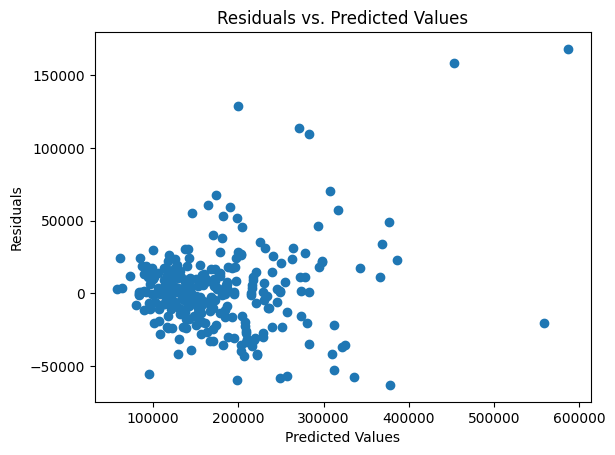

In [37]:
preds = best_elastic.predict(test_X)
preds = np.exp(preds)

residuals = test_y - preds

plt.scatter(preds, residuals)
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs. Predicted Values')
plt.show()

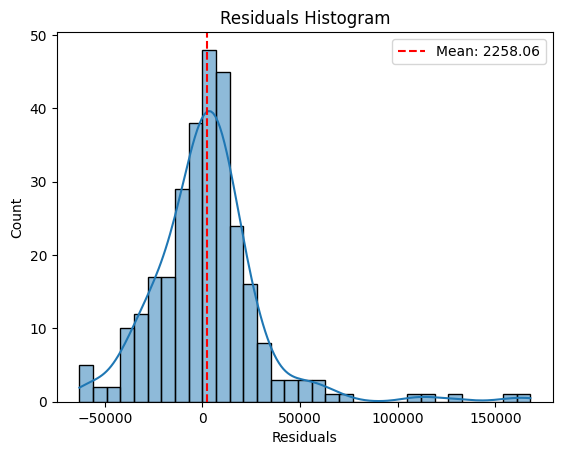

In [38]:
res_mean = residuals.mean()

sns.histplot(
    residuals, kde=True
)

plt.axvline(
    res_mean, linestyle='--',
    color='red', label=f'Mean: {res_mean:.2f}'
)

plt.title('Residuals Histogram')
plt.xlabel('Residuals')
plt.legend()
plt.show()

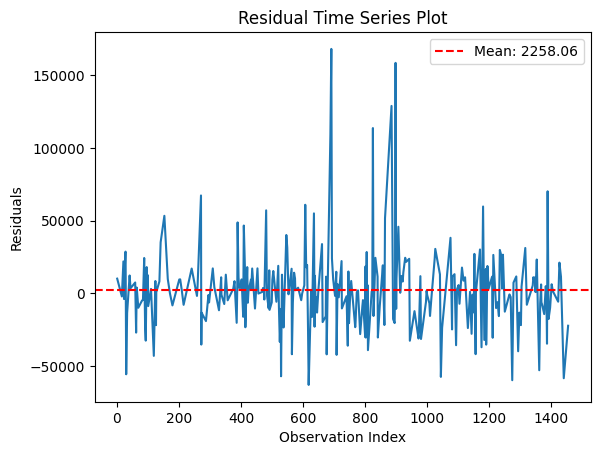

In [39]:
sns.lineplot(residuals)
plt.axhline(
    res_mean, linestyle='--',
    color='red', label=f'Mean: {res_mean:.2f}'
)

plt.title('Residual Time Series Plot')
plt.xlabel('Observation Index')
plt.ylabel('Residuals')
plt.legend()
plt.show()

## Residual Diagnostics Summary

The residual diagnostics indicate that the model is generally well-calibrated across the majority of the dataset, with prediction errors centered around zero and no strong global structural bias. Most residuals are relatively small, suggesting that the ElasticNet model captures the dominant linear relationships in the data effectively.

The residual histogram with KDE shows an approximately bell-shaped distribution, but with a clear right skew. This implies that while typical predictions are reasonably accurate, a small subset of observations generates large positive errors. These correspond to cases where the model systematically under-predicts high-value houses, creating a long tail in the error distribution.

The residual index plot further shows that these large errors are not sequentially clustered or patterned, but instead appear as isolated spikes. This suggests that the extreme errors are not driven by data ordering or systemic drift, but are instead associated with specific high-leverage observations or unusual property configurations.

In the residuals vs predicted values plot, a clear increase in error variance is observed as predicted values rise. This heteroscedastic pattern indicates that the model is more stable and reliable in the lower and mid-price ranges, but becomes progressively less accurate for expensive houses. The upper tail of the distribution contains the largest residuals, reinforcing that high-value properties are the main source of instability.

Overall, the ElasticNet model is statistically stable and performs well across the central distribution of housing prices. However, its performance degrades in the upper tail, where pricing behavior becomes more complex and less linear. The remaining error is therefore concentrated in extreme-value regimes rather than being uniformly distributed across the dataset, suggesting that the core linear structure has been captured, but tail behavior remains only partially modeled.

In [40]:
df_errors = pd.DataFrame({
    "y_true": test_y,
    "y_pred": preds,
})

df_errors["residual"] = df_errors["y_true"] - df_errors["y_pred"]
df_errors["abs_error"] = np.abs(df_errors["residual"])
df_errors["pct_error"] = df_errors["abs_error"] / df_errors["y_true"]

df_errors["price_segment"] = pd.qcut(
    df_errors["y_true"],
    q=5,
    labels=["very_low", "low", "mid", "high", "very_high"]
)

df_errors["error_segment"] = pd.qcut(
    df_errors["abs_error"],
    q=5,
    labels=["very_small", "small", "medium", "large", "extreme"]
)

df_errors["error_type"] = np.where(
    df_errors["residual"] > 0,
    "under_predict",
    "over_predict"
)

In [41]:
df_errors

,y_true,y_pred,residual,abs_error,pct_error,price_segment,error_segment,error_type
554,284000,283147.179999,852.820001,852.820001,0.003003,very_high,very_small,under_predict
1353,410000,386774.699704,23225.300296,23225.300296,0.056647,very_high,large,under_predict
126,128000,149879.853351,-21879.853351,21879.853351,0.170936,low,large,over_predict
841,157500,187869.220130,-30369.220130,30369.220130,0.192820,mid,extreme,over_predict
1088,137500,124339.960364,13160.039636,13160.039636,0.095709,low,medium,under_predict
...,...,...,...,...,...,...,...,...
481,374000,316975.513481,57024.486519,57024.486519,0.152472,very_high,extreme,under_predict
1244,230000,203456.641845,26543.358155,26543.358155,0.115406,very_high,large,under_predict
1401,193000,186779.716713,6220.283287,6220.283287,0.032229,high,small,under_predict
858,152000,142226.355804,9773.644196,9773.644196,0.064300,mid,small,under_predict


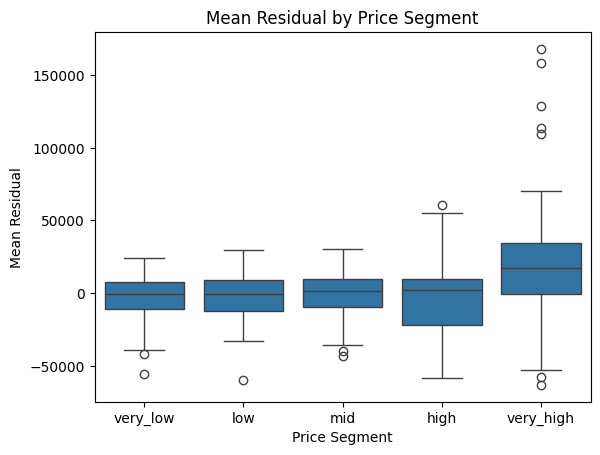

In [42]:
price_segment_mean = df_errors.groupby(
      "price_segment", observed=False
    )["residual"].mean()

sns.boxplot(
    data=df_errors,
    x='price_segment',
    y='residual'
)

plt.title('Mean Residual by Price Segment')
plt.xlabel('Price Segment')
plt.ylabel('Mean Residual')
plt.show()

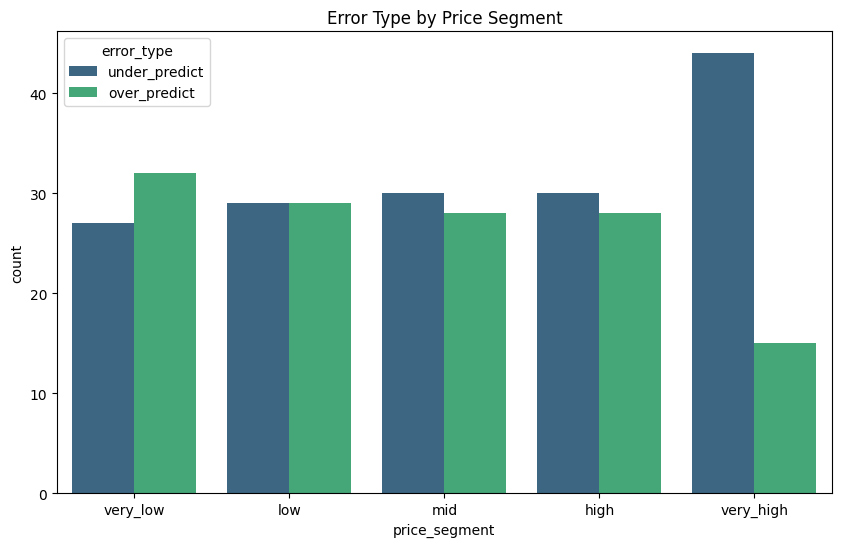

In [43]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df_errors, x='price_segment',
    hue='error_type', palette="viridis"
)
plt.title('Error Type by Price Segment')
plt.show()


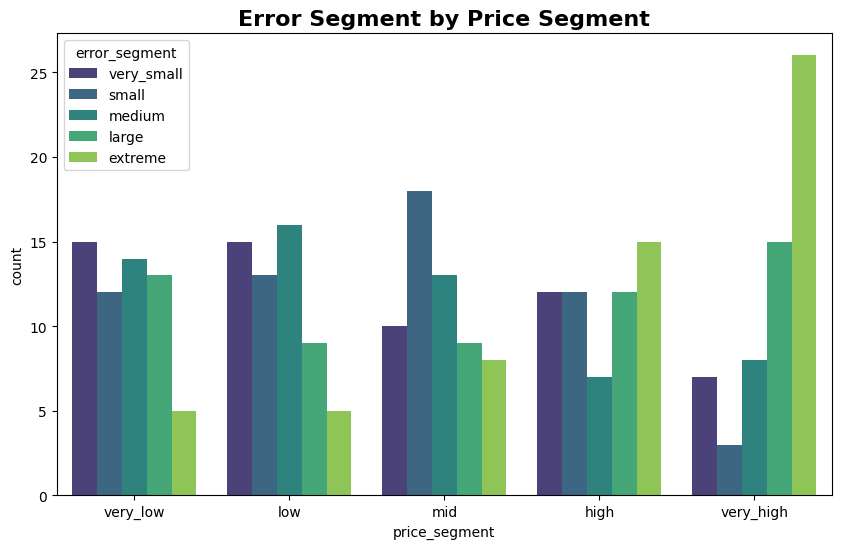

In [44]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df_errors, x='price_segment', hue='error_segment', palette="viridis")
plt.title(
    'Error Segment by Price Segment',
    fontsize=16,
    fontweight='bold'
)
plt.savefig('error_segment_chart.png', dpi=300)
plt.show()


The above plots further confirms that the model severely under-predicts houses with high prices, and that this severe under-prediction is the main source of instability in the model.

Further imporvements in the model could be made by separating these high price houses and modeling them separately to improve the model's performance.

# Project Summary

This project implemented a full regression pipeline on the Ames Housing dataset, covering data cleaning, feature engineering, encoding strategy design, multicollinearity reduction, and model evaluation across multiple linear and ensemble approaches.

A structured preprocessing pipeline was developed to handle heterogeneous variable types, including ordinal encoding for ordered categorical variables, one-hot encoding for nominal features, and targeted transformations (log/square-root) for skewed numerical distributions. In addition, several engineered features were introduced to better represent latent housing structure, such as age-based variables (e.g., house age, garage age, remodel age), binary presence indicators (e.g., has basement, has garage, has masonry veneer), and aggregated structural measures (e.g., total porch area).

To reduce redundancy in the feature space, strongly collinear numerical variables were either transformed into composite features or removed based on their overlap with more informative representations. This ensured that the final feature set captured unique signal contributions rather than repeated structural information.

Multiple regression models were evaluated, including Linear Regression, Ridge, Lasso, ElasticNet, Random Forest, and Histogram-based Gradient Boosting. Linear models with regularization (Ridge, Lasso, ElasticNet) demonstrated the most stable generalization performance, while tree-based models exhibited strong training performance but significant overfitting.

ElasticNet emerged as the most balanced model, achieving comparable performance to Ridge while maintaining stable generalization across train and test sets.

Residual diagnostics confirmed that the model performs well across the central distribution of house prices but exhibits increasing error variance and systematic under-prediction in the upper price range. This indicates that the remaining prediction error is concentrated in high-value, structurally complex properties rather than being uniformly distributed across the dataset.

---

## Conclusion

The final ElasticNet model provides a robust and interpretable baseline for housing price prediction, with strong generalization performance and controlled overfitting. However, the model’s limitations are most visible in the extreme upper tail of the price distribution, where linear assumptions fail to fully capture nonlinear luxury pricing dynamics.

Despite these limitations, the overall modeling pipeline successfully captures the dominant structural drivers of house prices, particularly in the mid-market segment, which constitutes the majority of observations.

---

## Further Improvements

Several directions could be explored to improve model performance, particularly in the high-value segment:

### 1. Nonlinear Feature Interactions
Explicit interaction terms (e.g., OverallQual × GrLivArea, Neighborhood × LotArea) could help capture structural nonlinearities that linear models cannot represent.

### 2. Advanced Tree-Based Regularization
Tree models such as Gradient Boosting, XGBoost, or LightGBM with stronger regularization and constrained depth could be revisited after feature refinement to reduce overfitting.

### 3. Outlier Treatment
Extreme-value houses should be further analyzed to determine whether they represent:
- data anomalies,
- rare structural configurations, or
- legitimate high-value market behavior.

Depending on this classification, they may be modeled separately or down-weighted.

### 4. Quantile or Robust Regression
Given the asymmetric error distribution, quantile regression could provide better performance in the upper tail by explicitly modeling conditional price distributions rather than mean estimates.

---

Overall, the pipeline establishes a strong baseline regression framework, with remaining improvements primarily concentrated in handling nonlinear structure and extreme-value behavior rather than correcting fundamental model instability.

In [45]:
import joblib

joblib.dump(best_elastic, 'best_elastic.joblib')

['best_elastic.joblib']